In [80]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 결측치 시각화를 위한 라이브러리
import missingno

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

# 다중공선성 확인을 위햔 라이브러리
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [18]:
train_df = pd.read_csv('4_청구입금정보_segment_병합.csv')
train_df

,Segment,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,...,할인금액_청구서_B0M,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액
0,3,201807,0,27,0,0,2,2,1,1,...,0,5,3,0,0,1,0,3,0,0
1,4,201807,1,13,0,1,5,4,1,1,...,163,6,3,0,0,0,0,0,0,0
2,2,201807,2,1,0,0,6,5,1,1,...,0,6,3,0,0,0,0,121,0,50
3,3,201807,3,5,0,1,5,4,1,1,...,0,5,3,2,0,0,0,3,0,2
4,4,201807,4,13,0,1,5,4,0,1,...,0,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,4,201812,399995,25,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0
2399996,3,201812,399996,20,0,0,6,5,1,1,...,0,6,3,0,0,0,0,164,0,53
2399997,2,201812,399997,20,0,2,5,4,1,1,...,0,6,3,0,0,0,0,0,0,0
2399998,4,201812,399998,20,0,1,5,4,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
X = train_df[['청구금액_B0', '청구금액_R3M', '청구금액_R6M']]
X = add_constant(X)

In [96]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400000 entries, 0 to 2399999
Data columns (total 4 columns):
 #   Column    Dtype  
---  ------    -----  
 0   const     float64
 1   청구금액_B0   int64  
 2   청구금액_R3M  int64  
 3   청구금액_R6M  int64  
dtypes: float64(1), int64(3)
memory usage: 73.2 MB


In [27]:
vif = pd.DataFrame()
vif["변수"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

         변수        VIF
0     const   1.465025
1   청구금액_B0  11.267904
2  청구금액_R3M  19.561144
3  청구금액_R6M   8.958861


- 청구금액_R6M 만 사용하여 EDA

In [38]:
train_df['청구금액_R6M'].describe()
train_df['Segment'].value_counts()

Segment
4    1922052
3     349242
2     127590
0        972
1        144
Name: count, dtype: int64

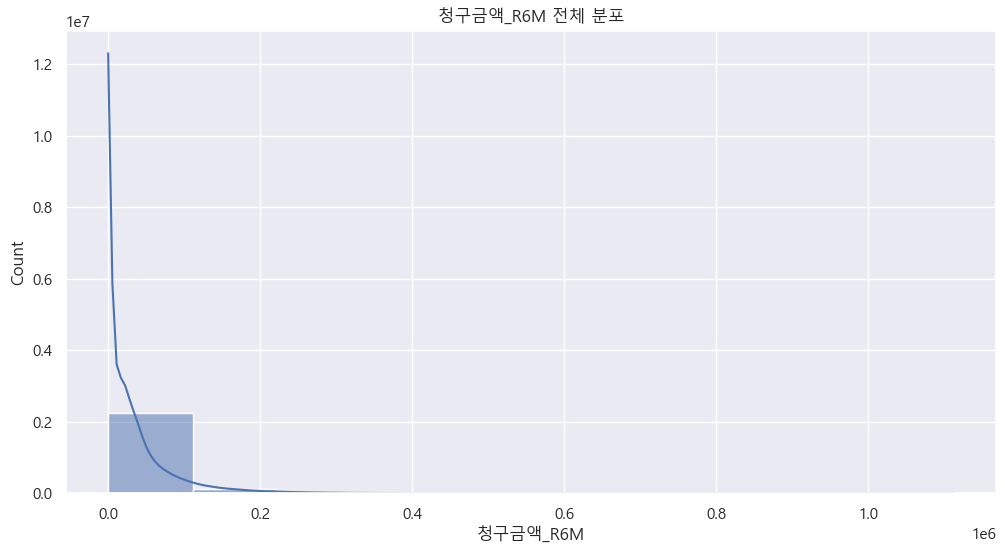

In [44]:
sns.histplot(train_df['청구금액_R6M'], bins=10, kde=True)
plt.title('청구금액_R6M 전체 분포')
plt.show()

In [50]:
Q1 = train_df['청구금액_R6M'].quantile(0.25)
Q3 = train_df['청구금액_R6M'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"IQR 기준 이상치 경계: {lower} ~ {upper}")
print(f"이상치 수: {(train_df['청구금액_R6M'] > upper).sum()}")

IQR 기준 이상치 경계: -60543.5 ~ 104844.5
이상치 수: 174712


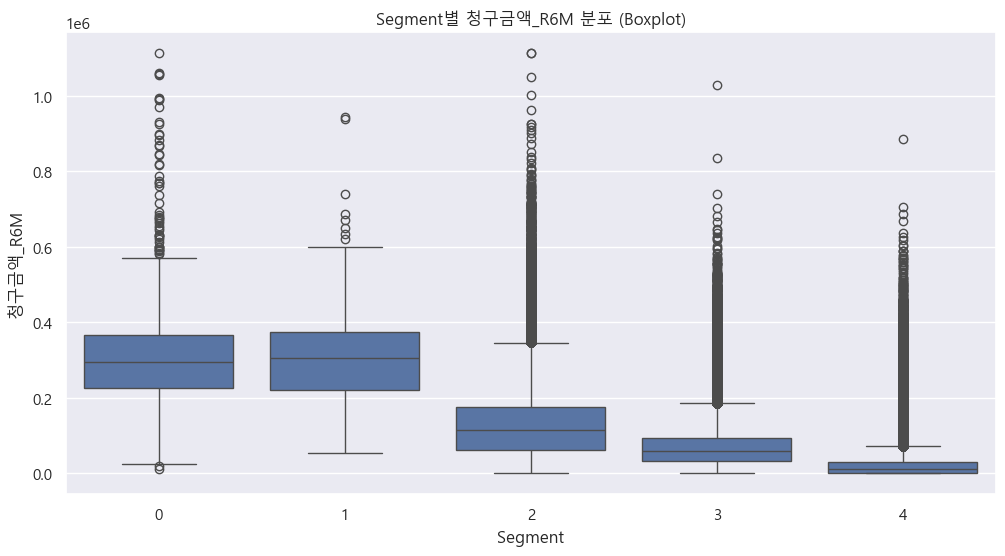

In [46]:
sns.boxplot(data=train_df, x='Segment', y='청구금액_R6M')
plt.title('Segment별 청구금액_R6M 분포 (Boxplot)')
plt.show()

In [48]:
train_df.groupby('Segment')['청구금액_R6M'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).reset_index()

,Segment,count,mean,median,std,min,max
0,0,972,316939.458848,294936.0,143058.580107,12056,1112355
1,1,144,316174.256944,305692.0,150900.827846,52478,944773
2,2,127590,128408.240129,115177.0,92340.265477,0,1112355
3,3,349242,69963.942264,59813.0,54680.502580,0,1027904
4,4,1922052,19778.687382,10091.0,28105.159733,0,885054


- 평균을 보면 0>1>2>3>4 순이다.
- 중앙값은 1>0>2>3>4 순이다.

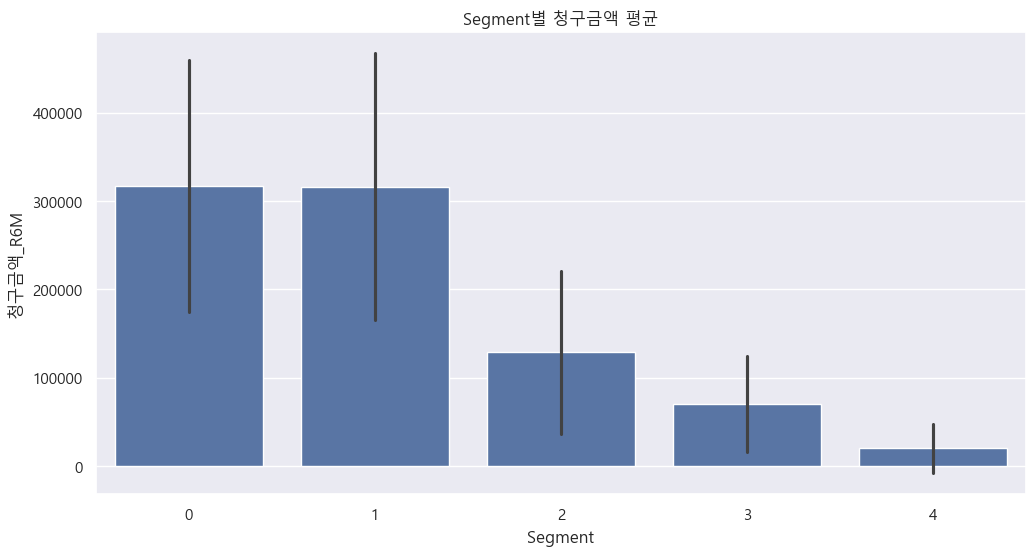

In [88]:
sns.barplot(x='Segment', y='청구금액_R6M', data=train_df, estimator='mean', ci='sd')
plt.title('Segment별 청구금액 평균')
plt.show()

In [92]:
from scipy.stats import f_oneway

groups = [group['청구금액_R6M'].dropna().values for name, group in train_df.groupby('Segment')]
f_stat, p_val = f_oneway(*groups)

print(f"F-통계량: {f_stat:.2f}, p-value: {p_val:.4f}")

F-통계량: 337197.62, p-value: 0.0000


### 결론 : 청구금액_R6M은 Segment를 잘 구분할 수 있는 요인 중 하나이다.